# Nonadiabatic Dynamics with Shin-Metiu Hamiltonians


## Table of Content: <a name="TOC"></a>

1. [Generic setups](#1)   

2. [Define Shin-Metiu model parameters](#2)

3. [Plotting the PES](#3)

4. [Choose the initial conditions: Nuclear and electronic](#4)

5. [Running the simulation](#5)

6. [Plotting the dynamics results](#6)



## A. Learning objectives

- Define model and dynamics parameters
- Initialize nuclear and electronic degrees of freedom
- Run the Ehrenfest dynamics (with other TSH methods as options) in polaritonic basis
- Plot the resulting dynamics


## B. Use cases

- Shin-Metiu dyanmics


## C. Functions


- libra_py
  - models
    - Shin_Metiu
      - shin_metiu_dvr
      - polariton
        - [compute_model](#compute_model-1)
  - dynamics
    - `tsh`
      - `compute`
        - [`generic_recipe`](#generic_recipe-1)
      - `plot`
        - [`plot_dynamics`](#plot_dynamics-1)     

## D. Classes and class members


## 1. Generic setups
<a name="1"></a>[Back to TOC](#TOC)

Here, we import all necessary libraries, set up some definitions (e.g. colors), and define the function that would be calling model Hamiltonians also defined within Libra package.

In [1]:
#Importing Required Libraries
import math
import numpy as np
import warnings
from functools import reduce
import matplotlib.pyplot as plt   # plots

# Core simulation modules
from libra_py.models.Shin_Metiu import shin_metiu_dvr
from libra_py.models.Shin_Metiu.shin_metiu_dvr import compute_model
from liblibra_core import *
import util.libutil as comn
from libra_py import units
import libra_py.dynamics.tsh.compute as tsh_dynamics
import libra_py.dynamics.tsh.plot as tsh_dynamics_plot

# Specific dynamics recipes
from recipes import ehrenfest_adi_ld, ehrenfest_dia, ehrenfest_adi_nac, fssh

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

colors = {}
colors.update({"11": "#8b1a0e"})  # red
colors.update({"12": "#FF4500"})  # orangered
colors.update({"13": "#B22222"})  # firebrick
colors.update({"14": "#DC143C"})  # crimson
colors.update({"21": "#5e9c36"})  # green
colors.update({"22": "#006400"})  # darkgreen
colors.update({"23": "#228B22"})  # forestgreen
colors.update({"24": "#808000"})  # olive
colors.update({"31": "#8A2BE2"})  # blueviolet
colors.update({"32": "#00008B"})  # darkblue
colors.update({"41": "#2F4F4F"})  # darkslategray

clrs_index = ["11", "21", "31", "41", "12", "22", "32", "13","23", "14", "24"]

<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWar

## 2. Define Shin-Metiu model parameters
<a name="2"></a>[Back to TOC](#TOC)

We define all important parameters for the Shin-Metiu models.
There are two different types of Shin-Metiu model (called as SM1 and SM2 respectively):

For the SM1, the electronic–nuclear potential is written as:

\begin{equation}
\hat{V}_{\mathrm{en}}=\sum_{\sigma= \pm 1}\left(\frac{1}{\left|R+\frac{\sigma L}{2}\right|}-\frac{\operatorname{erf}\left(\frac{\left|r+\frac{\sigma L}{2}\right|}{R_{\mathrm{c}}}\right)}{\left|r+\frac{\sigma L}{2}\right|}\right)-\frac{\operatorname{erf}\left(\frac{|R-r|}{R_{\mathrm{c}}}\right)}{|R-r|}
\end{equation}

For the SM2, the electronic–nuclear potential is written as:

\begin{equation}
\hat{V}_{\mathrm{en}}=\sum_{\sigma= \pm 1}\left(\frac{1}{\left|R+\frac{\sigma L}{2}\right|}-\frac{\operatorname{erf}\left(\frac{\left|r+\frac{\sigma L}{2}\right|}{a_\sigma}\right)}{\left|r+\frac{\sigma L}{2}\right|}\right)-\frac{\operatorname{erf}\left(\frac{|R-r|}{a_f}\right)}{|R-r|}
\end{equation}

Here we define the default parameters based on J. Chem. Phys. 157, 104118 (2022) paper.

In [2]:
# ===============================================================
# USER PARAMETERS
# ===============================================================

params = {
    "N": 300,
    "r_min": -22.0,
    "r_max": 22.0,
    "nstates": 2,
    "model": 1,
}

params["L_sm1"] = 18.897
params["Rc_sm1"] = 2.8345

# Range of R values
# For more accurate dynamics, use a finer grid
R_values = np.linspace(-8, 8, 21)

# ===============================================================
# RUN DVR SCAN
# ===============================================================

results = [compute_model(R, params) for R in R_values]

## 3. Plotting the PES
<a name="3"></a>[Back to TOC](#TOC)

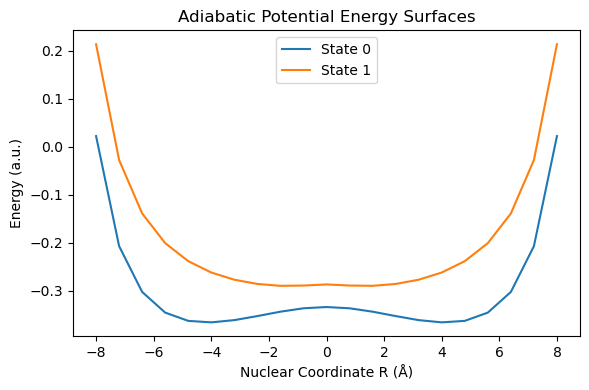

In [3]:
# ===============================================================
# PLOTTING EXAMPLE
# ===============================================================

energies = []
for i in range(params["nstates"]):
    energies.append(np.array([r.ham_adi.get(i,i) for r in results]))

plt.figure(figsize=(6,4))
for i in range(2):
    plt.plot(R_values, energies[i], label=f"State {i}")
plt.xlabel("Nuclear Coordinate R (Å)")
plt.ylabel("Energy (a.u.)")
plt.title("Adiabatic Potential Energy Surfaces")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Choose the initial conditions: Nuclear and Electronic
<a name="4"></a>[Back to TOC](#TOC)

In [11]:
# Initialization type for nuclear DOFs:
# 0: fixed coords and momenta
# 1: fixed coords, sampled momenta
# 2: sampled coords, fixed momenta
# 3: both coords and momenta sampled
# Here the paramters are set according to the J. Chem. Phys. 157, 104118 (2022) paper
icond_nucl = 3

nucl_params = {
    "ndof": 1,
    "q": [-7],                       # Initial position
    "p": [20],                      # Initial momentum
    "mass": [1836.0],                 # Proton mass in a.u.
    "force_constant": [0.000382**2 * 1836.0],
    "init_type": icond_nucl
}

#Initial Conditions：Electronic DOFs
# Representation:
# 0: diabatic wavefunctions
# 1: adiabatic wavefunctions
rep = 1

nstates = params["nstates"]
n_init = 0
# Initial population vector (all zeros except chosen initial state)
istates = [0.0] * nstates
istates[n_init] = 1.0

elec_params = {
    "verbosity": 2,
    "init_dm_type": 0,
    "ndia": nstates,
    "nadi": nstates,
    "rep": rep,
    "init_type": 0,
    "istates": istates,
    "istate": n_init
}

dyn_general = { "nsteps":500, "ntraj":1, "nstates":params["nstates"],
                "dt":0.1*units.fs2au, "num_electronic_substeps":1, "isNBRA":0, "is_nbra":0,
                "progress_frequency":0.1, "which_adi_states":range(nstates), "which_dia_states":range(nstates),      
                "mem_output_level":3,
                "properties_to_save":[ "timestep", "time", "q", "p", "f", "Cadi", "Cdia", "Epot_ave", "Ekin_ave", "Etot_ave",
                "se_pop_adi", "se_pop_dia", "sh_pop_adi", "sh_pop_dia", "mash_pop_adi", "mash_pop_dia"],
                "prefix":"adiabatic_md", "prefix2":"adiabatic_md"
              }

#ehrenfest_adi_ld.load(dyn_general)
#ehrenfest_dia.load(dyn_general)
ehrenfest_adi_nac.load(dyn_general)
dyn_general.update({"ham_update_method":2})  # recompute only adiabatic Hamiltonian; use with file-based or on-the-fly workflows
dyn_general.update( {"ham_transform_method":0 }) # don't do any transforms; usually for NBRA or on-the-fly workflows,
dyn_params = dict(dyn_general)

## 6. Running the Simulation
<a name="6"></a>[Back to TOC](#TOC)

Running dynamics

In [12]:
# Create a random number generator for stochastic parts
rnd = Random()

params["model0"] = 1
# Run the Ehrenfest simulation
res = tsh_dynamics.generic_recipe(
    dyn_params,
    compute_model,
    params,
    elec_params,
    nucl_params,
    rnd
)

Active states (adiabatic)
[0]
Initial adiabatic populations
[1.0, 0.0]
======= Initialization type is 0 ========
setting representation 1 coefficient C_0 to 1.0
========== ampl_dia ===============
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  

========== ampl_adi ===============
(1.0000000,0.0000000)  
(0.0000000,0.0000000)  

========== states ===============
======= Initialization type is 0 ========
setting DM in representation 1 using wfc amplitudes 
 step= 0
In cctor: lvl = 1 der_lvl = 2
 step= 50
 step= 100
 step= 150
 step= 200
 step= 250
 step= 300
 step= 350
 step= 400
 step= 450
In mem_saver.save_data()
data_name =  ['timestep', 'time', 'q', 'p', 'f', 'Cadi', 'Cdia', 'Epot_ave', 'Ekin_ave', 'Etot_ave', 'se_pop_adi', 'se_pop_dia', 'sh_pop_adi', 'sh_pop_dia', 'mash_pop_adi', 'mash_pop_dia']
keywords =  ['timestep', 'time', 'q', 'p', 'f', 'Cadi', 'Cdia', 'Epot_ave', 'Ekin_ave', 'Etot_ave', 'se_pop_adi', 'se_pop_dia', 'sh_pop_adi', 'sh_pop_dia', 'mash_pop_adi', 'mash_pop_dia']
k

## 5. Plotting the results
<a name="5"></a>[Back to TOC](#TOC)

Plotting the quantities

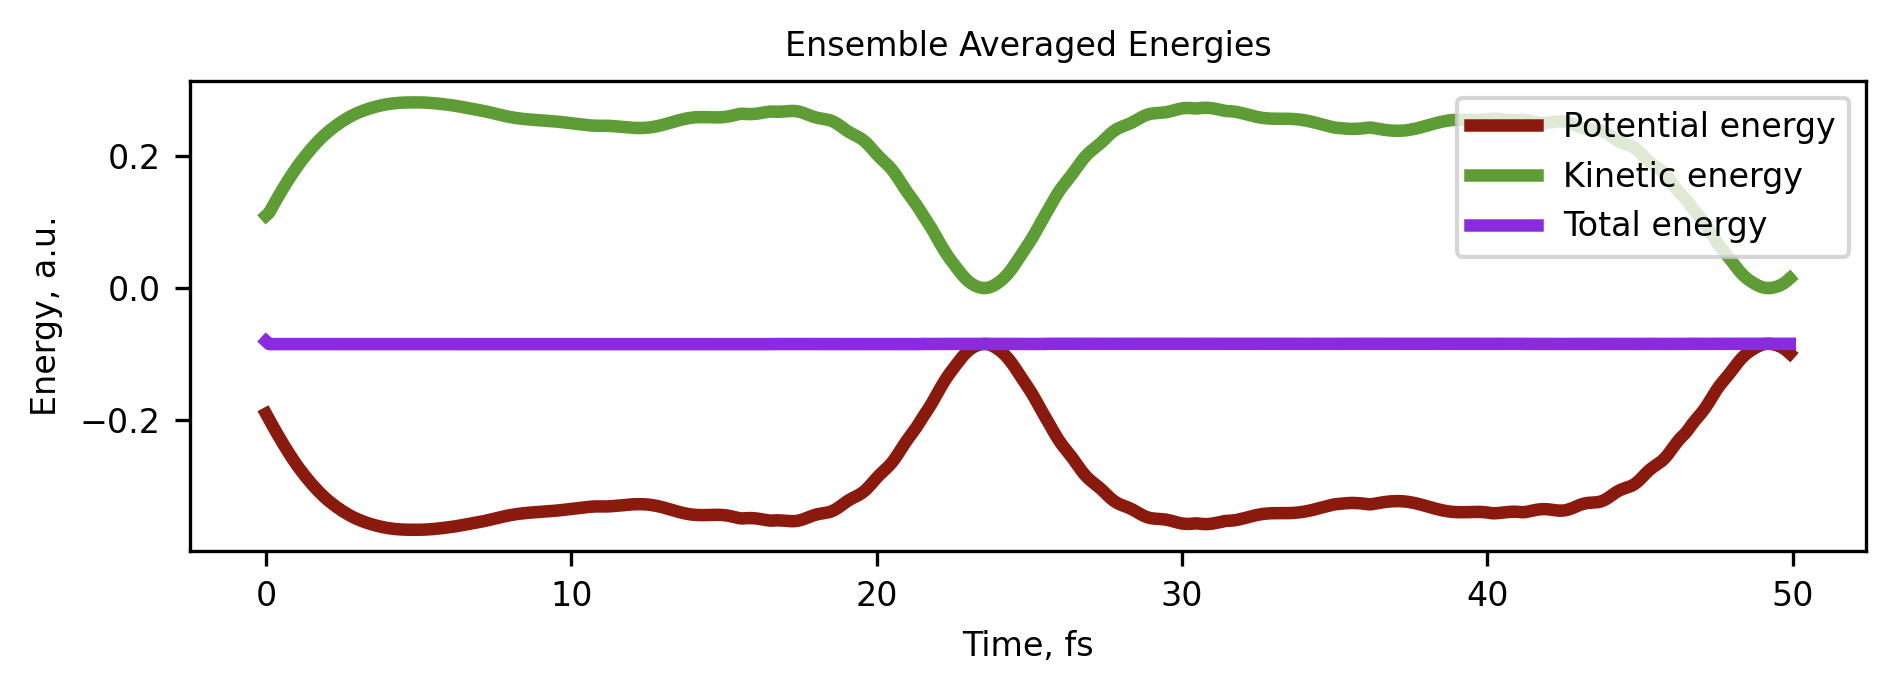

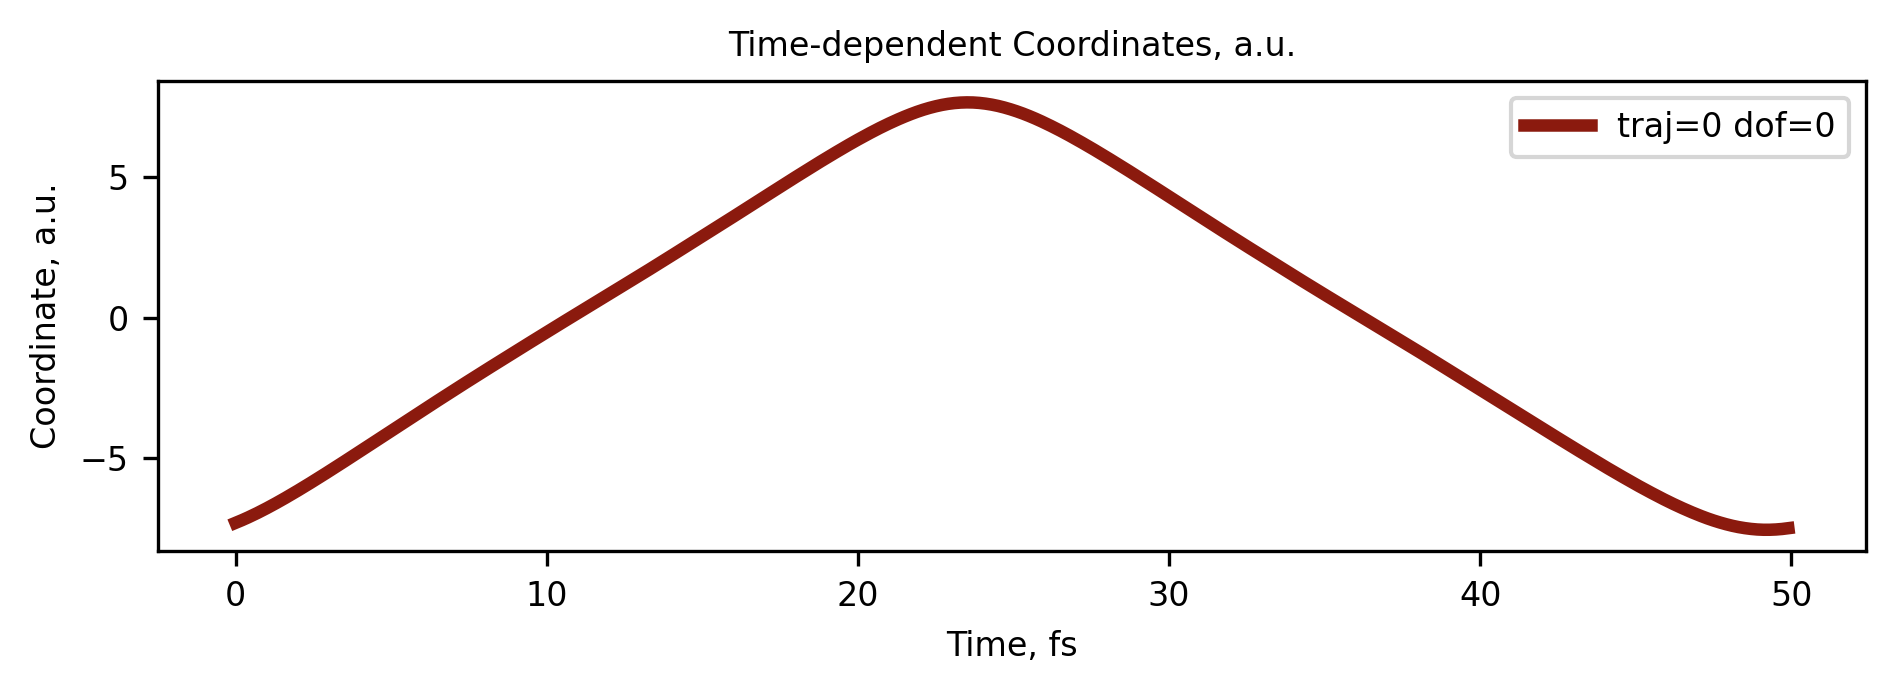

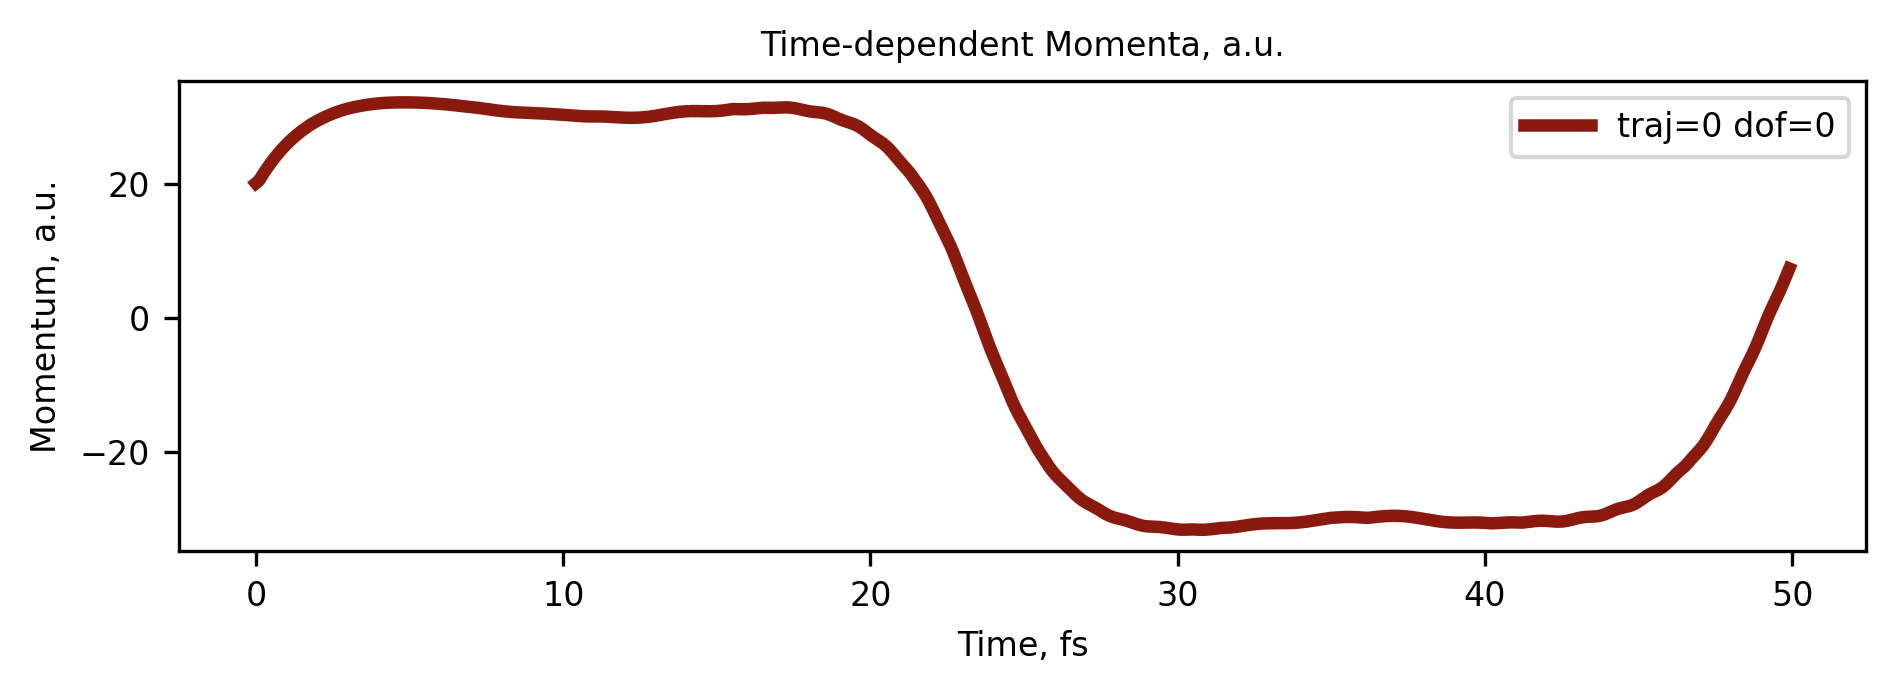

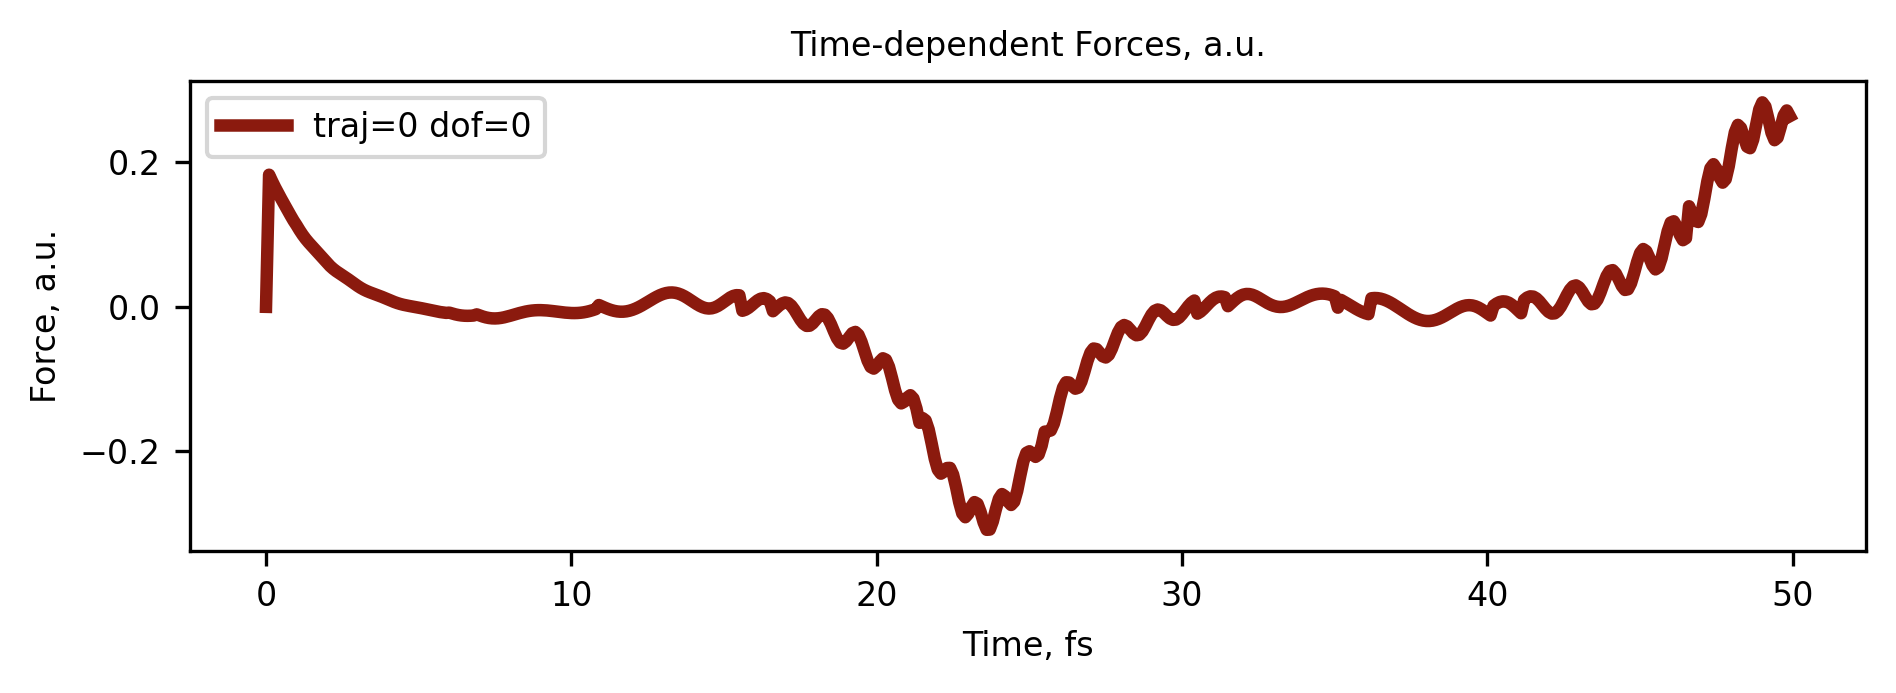

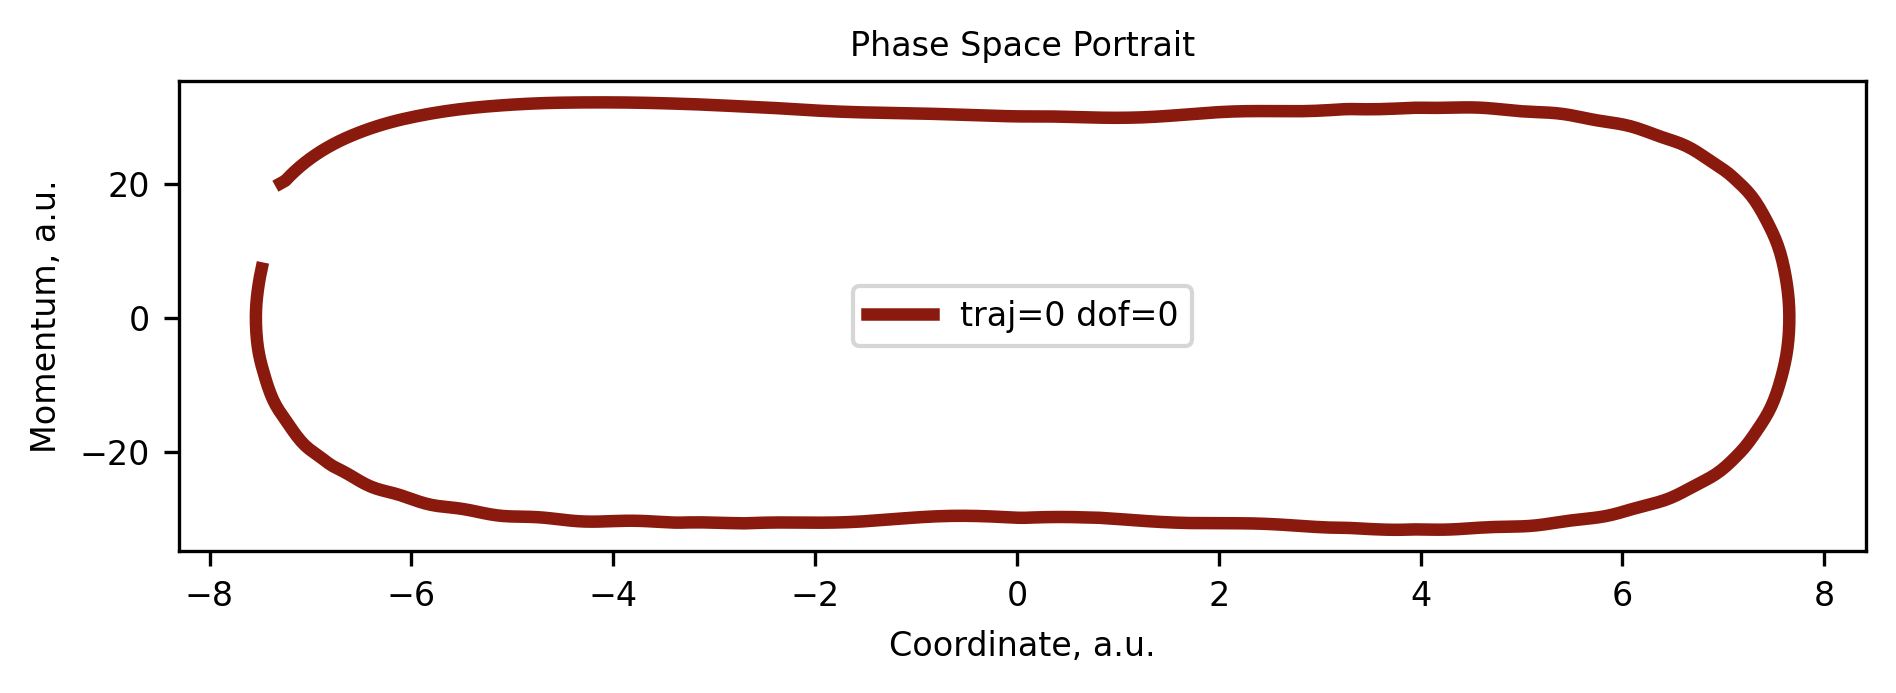

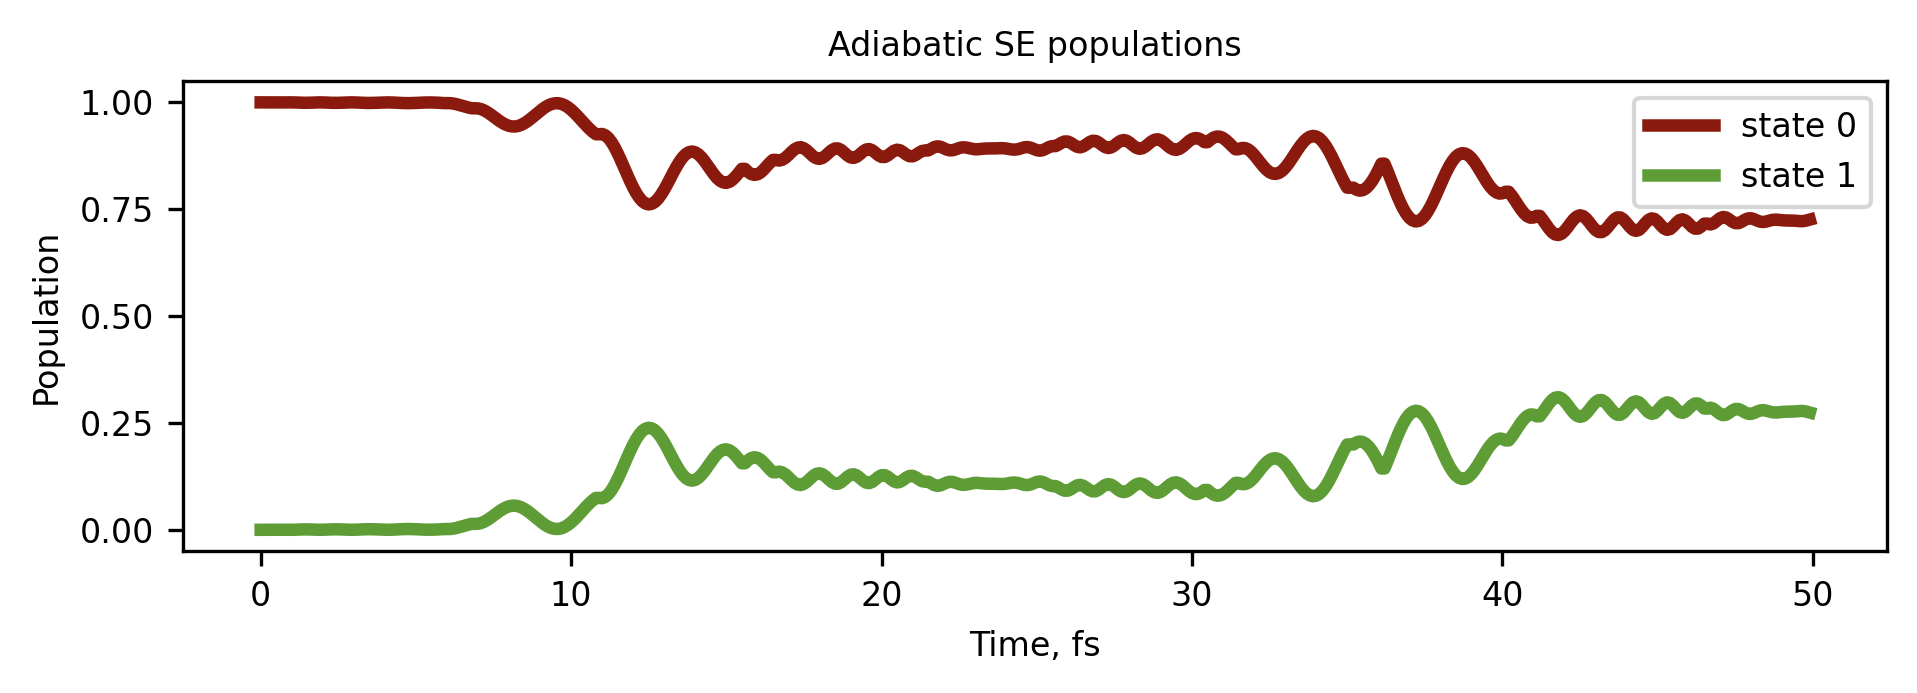

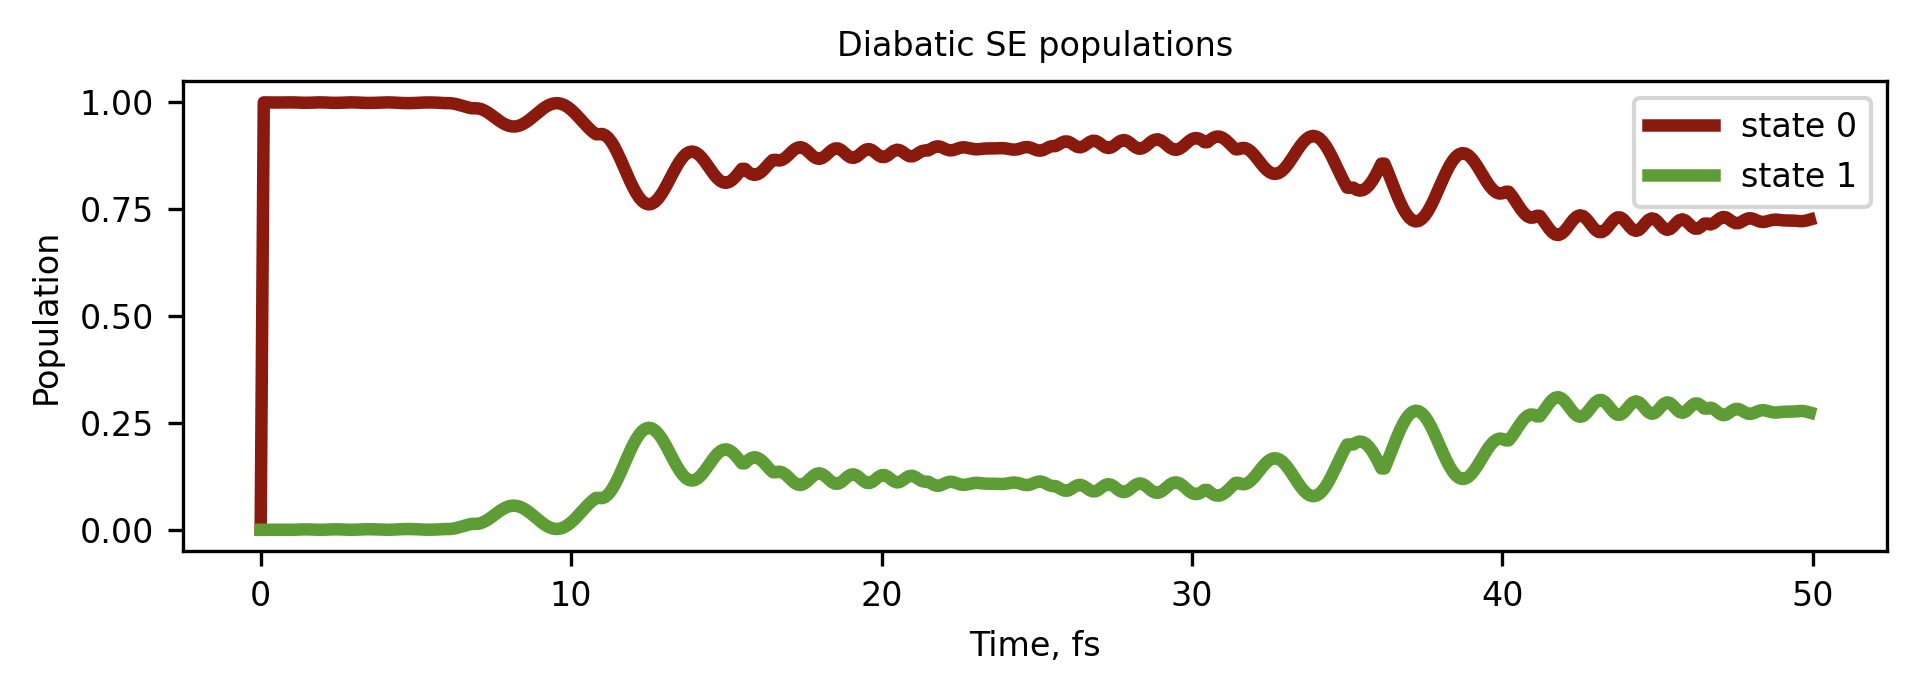

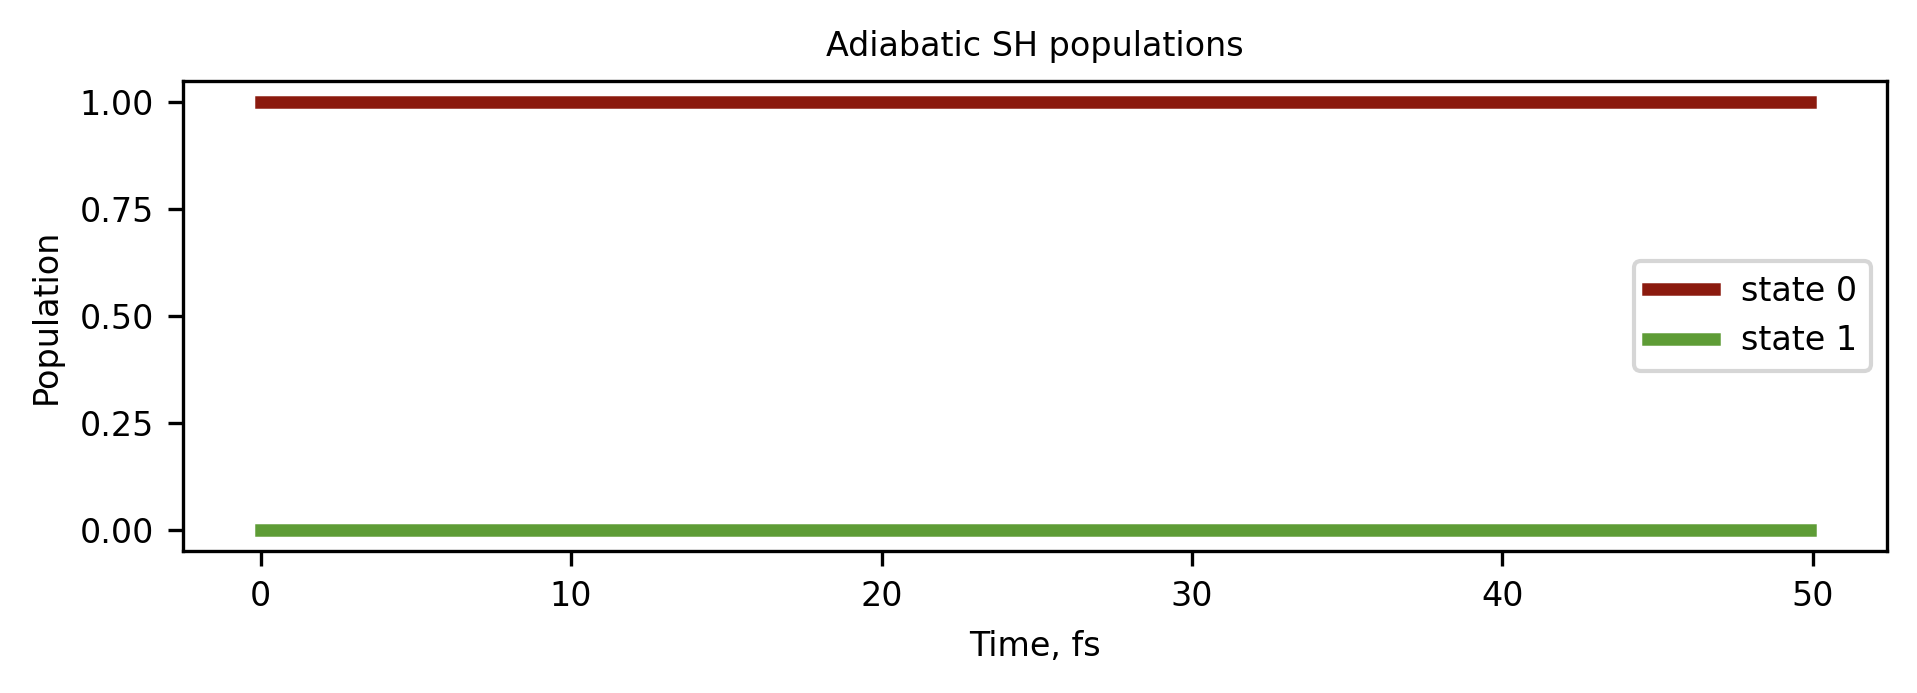

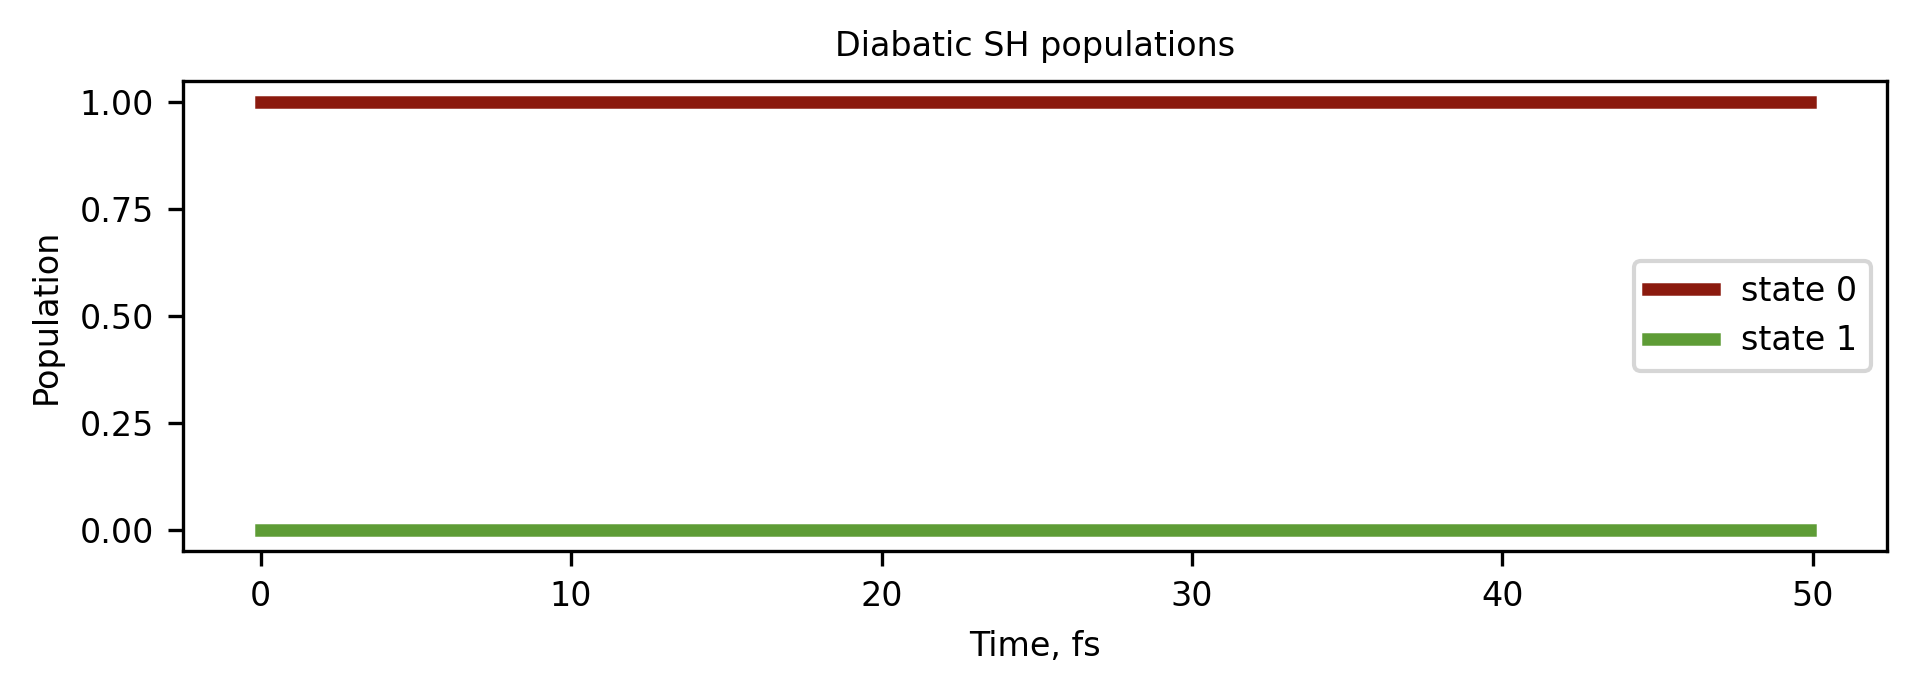

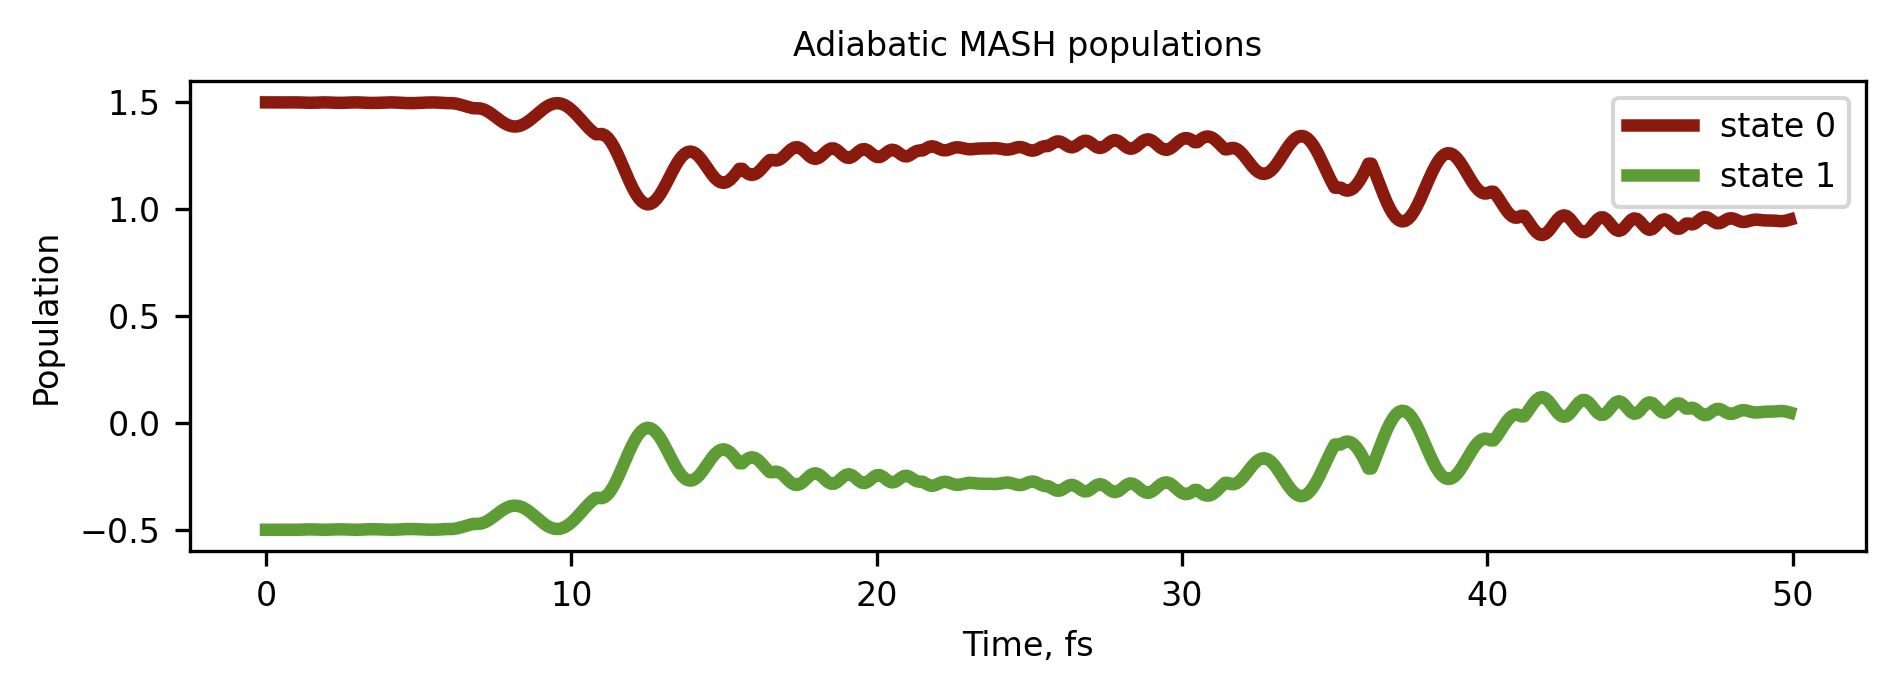

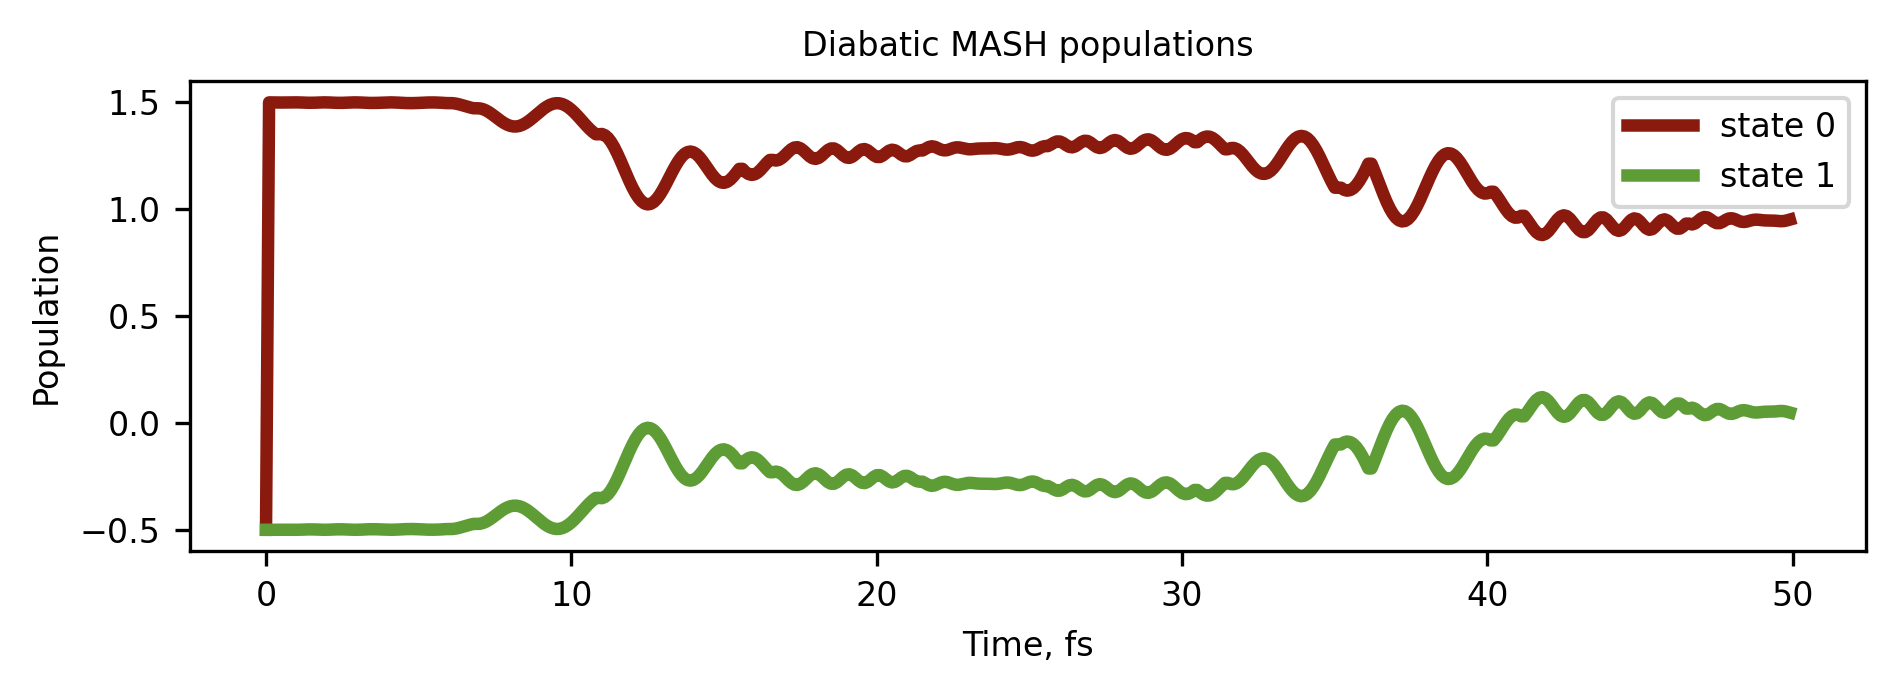

In [13]:

plot_params = {
    "prefix": "adiabatic_md",
    "filename": "mem_data.hdf",
    "output_level": 3,
    "which_trajectories": [0],
    "which_dofs": [0],
    "which_adi_states": list(range(nstates)),
    "which_dia_states": list(range(nstates)),
    "frameon": True,
    "linewidth": 3,
    "dpi": 300,
    "axes_label_fontsize": (8,8),
    "legend_fontsize": 8,
    "axes_fontsize": (8,8),
    "title_fontsize": 8,
    "what_to_plot": [
        "coordinates", "momenta",  "forces", "energies", "phase_space",
        "se_pop_adi", "se_pop_dia", "sh_pop_adi", "sh_pop_dia",
        "mash_pop_adi", "mash_pop_dia"
    ],
    "which_energies": ["potential", "kinetic", "total"],
    "save_figures": 1,
    "do_show": 1
}

tsh_dynamics_plot.plot_dynamics(plot_params)